In [1]:
# For training and performance analysis
import torch
from torch import nn
from torch.nn import functional as F
from torch import optim
import dlc_practical_prologue as prologue
import time

# For visualisation
import matplotlib.pyplot as plt
%matplotlib inline

### Train parameters (global)

In [2]:
SEED = 10 #int(time.time())
torch.manual_seed(SEED)

N = 1000
BATCH_SIZE = 15
EPOCHS = 200

LEARNING_RATE = 1e-3
LR_STEP = 100
GAMMA = 0.1

FIX_MNIST = 1 # Fix MnistNet parameters after FIX_MNIST * EPOCHS epochs
VERBOSE_FREQ = 10 # Show verbose every VERBOSE_FREQ epochs

ROUNDS = 10 # Number of rounds for validation


### Data loading

Data statistics function.

In [3]:
def data_statistics(train_input, train_target, train_classes, test_input, test_target, test_classes):
    
    print("Traing data:\n"
          "   -Train input: {}\n".format(train_input.shape) + \
          "   -Train target: {}\n".format(train_target.shape) + \
          "   -Train classes: {}\n".format(train_classes.shape))
    print("Test data:\n"
          "   -Test input: {}\n".format(test_input.shape) + \
          "   -Test target: {}\n".format(test_target.shape) + \
          "   -Test classes: {}".format(test_classes.shape))

def sample_showcase(idx, inputs, targets, classes):
    
    n1_img, n2_img =  inputs[idx,0,:,:], inputs[idx,1,:,:]
    t = targets[idx]
    c1, c2 = classes[idx,0], classes[idx,1]
    
    plt.figure(figsize=(6, 3.7))
    plt.suptitle('Sample {} (target = {})'.format(idx, t))
        
    plt.subplot(121)
    plt.title('First channel\n (class = {})'.format(c1))
    plt.imshow(n1_img, cmap='Greys')
    
    plt.subplot(122)
    plt.title('Secont channel\n (class = {})'.format(c2))
    plt.imshow(n2_img, cmap='Greys')
   


In [4]:
# Load data 
train_input, train_target, train_classes, test_input, test_target, test_classes = prologue.generate_pair_sets(N)

Traing data:
   -Train input: torch.Size([1000, 2, 14, 14])
   -Train target: torch.Size([1000])
   -Train classes: torch.Size([1000, 2])

Test data:
   -Test input: torch.Size([1000, 2, 14, 14])
   -Test target: torch.Size([1000])
   -Test classes: torch.Size([1000, 2])


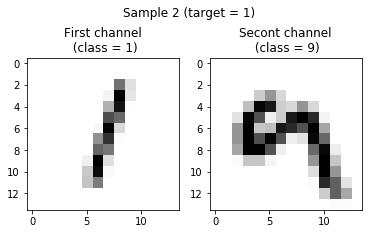

In [5]:
# Print data statistics
data_statistics(train_input, train_target, train_classes, test_input, test_target, test_classes)

# Showcase of one sample
sample_showcase(2, train_input, train_target, train_classes)

### Helper functions

Accuracy and weight reset functions.

In [6]:
def accuracy(model_output, test_target):
    """Return the accuracy of the model output."""
    nb_samples = model_output.shape[0]
    output_int = torch.zeros(nb_samples)
    
    # Convert probability to decision
    output_int = torch.argmax(model_output, 1)
    
    nb_errors = (output_int - test_target).type(torch.BoolTensor).sum().item()
    return (nb_samples - nb_errors) / nb_samples

def accuracyMnist(model_output, test_target):
    nb_samples = model_output.shape[0]
    model_class = model_output.argmax(dim=1)
    nb_errors = (model_class - test_target).type(torch.BoolTensor).sum().item()
    return (nb_samples - nb_errors) / nb_samples
    
    
def weight_reset(m):
    """Reset the parameters of the model"""
    if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
        #nn.init.xavier_uniform_(m.weight, gain=nn.init.calculate_gain('relu'))
        #other (mysterious) method
        m.reset_parameters()

### Neural Nets construction

In [15]:
class MnistNetV1(nn.Module):
    def __init__(self):
        super(MnistNetV1, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=5, padding=1) #(1,14,14) to (32,12,12)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3) #(32,12,12) to (64,10,10)
        self.max_pool1 = nn.MaxPool2d(kernel_size=2, stride=2) #(64,10,10) to (64,5,5)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=2) #(64,5,5) to (128,4,4) 
        self.max_pool2 = nn.MaxPool2d(kernel_size=3, stride=1) #(128,4,4) to (128,2,2)
        self.fc = nn.Linear(512, 10)
        self.drop2d = nn.Dropout2d(0.25)

    def forward(self, x):   
        x = self.conv1(x)
        x = F.relu(x)
        x = self.conv2(x)
        x = F.relu(x)
        x = self.max_pool1(x)
        x = self.drop2d(x)
        
        x = self.conv3(x)
        x = F.relu(x)
        x = self.max_pool2(x)
        x = self.drop2d(x)
        
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        
        return x, None, None

class MnistNetV2(nn.Module):
    def __init__(self):
        super(MnistNetV2, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3) #(1,14,14) to (32,12,12)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3) #(32,12,12) to (64,10,10)
        self.max_pool1 = nn.MaxPool2d(kernel_size=2, stride=2) #(64,10,10) to (64,5,5)
        self.fc1 = nn.Linear(1600, 128)
        self.fc2 = nn.Linear(128, 10)
        
        self.drop25 = nn.Dropout(0.25)
        self.drop50 = nn.Dropout(0.5)
        
    def forward(self, x):   
        x = self.conv1(x)
        x = F.relu(x)
        x = self.conv2(x)
        x = F.relu(x)
        x = self.max_pool1(x)
        x = self.drop25(x.view(x.size(0), -1))
        x = self.fc1(x)
        x = F.relu(x)
        x = self.drop50(x)
        x = self.fc2(x)
        
        return x, None, None


class MnistNetV3(nn.Module):
    """Inspired by LeNet4"""
    def __init__(self):
        super(MnistNetV3, self).__init__()
        self.conv1 = nn.Conv2d(1, 4, kernel_size=3) #(1,14,14) to (4,12,12)
        self.conv2 = nn.Conv2d(4, 16, kernel_size=3) #(4,12,12) to (16,10,10)
        self.max_pool1 = nn.MaxPool2d(kernel_size=2, stride=2) #(16,10,10) to (16,5,5)
        self.fc1 = nn.Linear(400, 120)
        self.fc2 = nn.Linear(120, 10)
        
        self.drop25 = nn.Dropout(0.25)
        self.drop50 = nn.Dropout(0.5)
        
    def forward(self, x):   
        x = self.conv1(x)
        x = F.relu(x)
        x = self.conv2(x)
        x = F.relu(x)
        x = self.max_pool1(x)
        x = self.drop50(x.view(x.size(0), -1))
        x = self.fc1(x)
        x = F.relu(x)
        x = self.drop50(x)
        x = self.fc2(x)
        
        return x, None, None
    
#Model : BasicNet with MnistNetV2 
#Number of trained parameters : 225496
#Train data size : 1000
#Size of mini-batches : 20
#Number of epochs per round: 100
#Time for 10 rounds : 881.49s
#Average main performance (and standard deviation):
#    -Train accuracy : 99.82% (+-0.50%)
#    -Test accuracy : 93.56% (+-0.93%)
#Average auxiliary performance (and standard deviation):
#    -Train Mnist accuracy : 100.00% (+-0.00%)
#    -Test Mnist accuracy : 95.55% (+-0.23%)

class BasicNetV1(nn.Module):
    def __init__(self):
        super(BasicNetV1, self).__init__()
        self.mnistNet = MnistNetV3()
        self.fc1 = nn.Linear(20,20)
        self.fc2 = nn.Linear(20,2)
        self.drop = nn.Dropout(0.5)
        self.activation = nn.Sigmoid()


    def forward(self, x):
        x1, x2 = x[:,0:1,:,:], x[:,1:2,:,:]
        x1, _, _ = self.mnistNet(x1)
        x2, _, _ = self.mnistNet(x2)       
        x = torch.cat((x1, x2), 1)
        x = self.fc1(x)
        x = F.relu(x)
        x = self.drop(x)
        x = self.fc2(x)
        
        return x, x1, x2
    
class BasicNetV2(nn.Module):
    def __init__(self):
        super(BasicNetV2, self).__init__()
        self.mnistNet = MnistNetV3()
        self.fc1 = nn.Linear(20,10)
        self.fc2 = nn.Linear(10,2)
        self.drop = nn.Dropout(0.5)
        self.activation = nn.Sigmoid()


    def forward(self, x):
        x1, x2 = x[:,0:1,:,:], x[:,1:2,:,:]
        x1, _, _ = self.mnistNet(x1)
        x2, _, _ = self.mnistNet(x2)       
        x = torch.cat((x1, x2), 1)
        x = self.fc1(x)
        x = F.relu(x)
        #x = self.drop(x)
        x = self.fc2(x)
        
        return x, x1, x2
    

### Training

Function for main and auxiliary losses ponderation.

In [16]:
def aux_loss_coeff(e):
    """ Return the weight of the auxiliary loss at epoch e."""
    f = 0.5
    
    
    #if e >= 1*EPOCHS//2:
    #    f = 0.8
    
    return f

Verbose and summary rountine for the main training routine.

In [17]:
def verbose_routine(model, criterion, epoch,
                    train_input, train_target, train_classes,
                    test_input, test_target, test_classes):
    "Display verbose during the current epoch."
    # Compute model outputs
    model.train(False)
    tr_output, tr_aux1, tr_aux2 = model(train_input)
    te_output, te_aux1, te_aux2 = model(test_input)
    model.train(True) 

    # Compute performance using model outputs
    tr_loss = criterion(tr_output, train_target)
    te_loss = criterion(te_output, test_target)
    
    tr_acc = accuracy(tr_output, train_target)
    te_acc = accuracy(te_output, test_target)
    
    tr_acc_mnist = 0.5*(accuracyMnist(tr_aux1, train_classes[:,0]) +\
                           accuracyMnist(tr_aux2, train_classes[:,1]))
    te_acc_mnist = 0.5*(accuracyMnist(te_aux1, test_classes[:,0]) +\
                         accuracyMnist(te_aux2, test_classes[:,1]))

    # Display result
    print("Epoch {}:\n".format(epoch) + \
          "Train loss : {:.3f},      |   Test loss : {:.6f}\n".format(tr_loss, te_loss) +\
          "Train acc : {:.3f},       |   Test acc : {:.3f}\n".format(tr_acc, te_acc) +\
          "Train acc mnist : {:.3f}, |   Test acc mnist : {:.3f}\n".format(tr_acc_mnist, te_acc_mnist) +\
          "-----------")

In [18]:
def summary_routine(model, track_history, verbose, history):
    """Print summary of the model properties and performance at the end of the training."""
    total_trained_params = sum(p.numel() for p in model.parameters())

    # Training time relevance
    warning =""
    if track_history or verbose:
        if not verbose:
            warning = "(history active)"
        elif not track_history:
            warning = "(verbose active)"
        else:
            warning = "(history and verbose active)"
            
    print("Model : {} with {} \n".format(model.__class__.__name__ , model.mnistNet.__class__.__name__) + \
          "Number of trained parameters : {}\n".format(total_trained_params) + \
          "Train data size : {}\n".format(N) + \
          "Size of mini-batches : {}\n".format(BATCH_SIZE) + \
          "Time for {} epochs : {:.2f}s {}\n".format(EPOCHS, history["t_elapsed"], warning) + \
          "Main performance:\n" + \
          "    -Train accuracy : {:.2f}%\n".format(100 * history["tr_acc_hist"][-1]) + \
          "    -Test accuracy : {:.2f}%\n".format(100 * history["te_acc_hist"][-1]) + \
          "Auxiliary performance:\n" + \
          "    -Train Mnist accuracy : {:.2f}%\n".format(100 * history["tr_acc_mnist_hist"][-1]) + \
          "    -Test Mnist accuracy : {:.2f}%\n".format(100 * history["te_acc_mnist_hist"][-1]) + \
          "-----------------------------------")

Dictionaries initialization routine and update routing for history.

In [19]:
def dictionary_init(track_history, rounds=0):
    """Initialize the histroy (or round statistics) dictionary."""
    # For history dictionary
    sz_time = rounds # For history dictionaries, history["t_elapsed"] will be overriden by a float and sz_time doesn't matter. 
    if rounds == 0:
        if track_history:
            sz = EPOCHS # Store performance at each epoch
        else:
            sz = 1 # Store only the final performance
                  
    # For rounds stats dictionary
    else:
        if track_history:
            sz = (rounds,EPOCHS) # Store performance at each round and epoch 
        else:
            sz = (rounds,1) # Store only the final performance for each round
    
    # Arrays to store history of performance during training (or only last value if history is False)
    dictionary = {
    "tr_loss_hist" : torch.zeros(sz),
    "te_loss_hist" : torch.zeros(sz),
    "tr_acc_hist" : torch.zeros(sz),
    "te_acc_hist" : torch.zeros(sz),
    "tr_acc_mnist_hist" : torch.zeros(sz),
    "te_acc_mnist_hist" : torch.zeros(sz),
    "t_elapsed" : torch.zeros(sz_time)}
    
    return dictionary

In [20]:
def history_routine_(history, model, criterion, idx,
                     train_input, train_target, train_classes,
                     test_input, test_target, test_classes):
    """Update (in place) the model performance history at epoch."""
    # Compute model outputs
    model.train(False)
    tr_output, tr_aux1, tr_aux2 = model(train_input)
    te_output, te_aux1, te_aux2 = model(test_input)
    model.train(True) 

    # Compute performance using model outputs
    tr_loss = criterion(tr_output, train_target).detach()
    te_loss = criterion(te_output, test_target).detach()
    
    tr_acc = accuracy(tr_output, train_target)
    te_acc = accuracy(te_output, test_target)
    
    tr_acc_mnist = 0.5*(accuracyMnist(tr_aux1, train_classes[:,0]) +\
                           accuracyMnist(tr_aux2, train_classes[:,1]))
    te_acc_mnist = 0.5*(accuracyMnist(te_aux1, test_classes[:,0]) +\
                         accuracyMnist(te_aux2, test_classes[:,1]))
    
    # Updating history tensors
    history["tr_loss_hist"][idx] = tr_loss
    history["te_loss_hist"][idx] = te_loss
    history["tr_acc_hist"][idx] = tr_acc
    history["te_acc_hist"][idx] = te_acc
    history["tr_acc_mnist_hist"][idx] = tr_acc_mnist
    history["te_acc_mnist_hist"][idx] = te_acc_mnist

Main train routine.

In [21]:
def train_routine(model, train_input, train_target, train_classes,
                  test_input, test_target, test_classes,
                  verbose=True, track_history=True, summary=True, param_init=False):
    """Train a model, print the results and return the train and validation loss."""
    
    # Loss
    criterion = nn.CrossEntropyLoss()
    
    # Optimizer
    optimizer = optim.Adam(model.parameters(), LEARNING_RATE)
    
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=LR_STEP, gamma = GAMMA)
    
    # Initialize array to store history
    history = dictionary_init(track_history)
    
    # Start timer
    t0 = time.time() 
    
    # Parameters initialization
    if param_init:
        model.apply(weight_reset) 
    
    # Training the model
    model.train(True)
    
    for e in range(EPOCHS):
    
        # Fixing MnistNet parameters after a certain number of epochs
        for p in model.mnistNet.parameters():
            p.requires_grad =  (e < FIX_MNIST * EPOCHS)
            
        # Ponderation of the final loss => (1-f): ponderation of the auxiliray loss
        f = aux_loss_coeff(e)

        for inputs, targets, classes in zip(train_input.split(BATCH_SIZE), 
                                            train_target.split(BATCH_SIZE),
                                            train_classes.split(BATCH_SIZE)):
            
            output, aux1, aux2 = model(inputs)
            
            if aux1 is not None and aux2 is not None:
                loss = f*criterion(output, targets) + (1-f)*(criterion(aux1, classes[:,0]) + criterion(aux2, classes[:,1]))
            else:
                loss = criterion(output, targets)
                
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        
        # Updtate learning rate
        scheduler.step()
            
        # Verbose for direct feedback
        if verbose:
            if((e + 1) % VERBOSE_FREQ == 0):
                verbose_routine(model, criterion, e+1,
                                train_input, train_target, train_classes,
                                test_input, test_target, test_classes)

        # History for post training analysis
        if track_history:
            history_routine_(history, model, criterion, e,
                             train_input, train_target, train_classes,
                             test_input, test_target, test_classes)
    
    # End timer
    t1 = time.time() 
    dt = t1-t0
    history["t_elapsed"] = dt
    
    if not track_history:
        # Compute and store model accuracy
        history_routine_(history, model, criterion, 0,
                         train_input, train_target, train_classes,
                         test_input, test_target, test_classes)
    if summary:
        # Display model performance
        summary_routine(model, track_history, verbose, history)
    
    model.train(False)
    
    return  history


In [22]:
model = BasicNetV2()
history = train_routine(model, 
                        train_input, train_target, train_classes,
                        test_input, test_target, test_classes,
                        verbose=True, track_history=False)

Epoch 10:
Train loss : 0.336,      |   Test loss : 0.370210
Train acc : 0.885,       |   Test acc : 0.863
Train acc mnist : 0.959, |   Test acc mnist : 0.942
-----------
Epoch 20:
Train loss : 0.203,      |   Test loss : 0.260004
Train acc : 0.935,       |   Test acc : 0.890
Train acc mnist : 0.985, |   Test acc mnist : 0.956
-----------
Epoch 30:
Train loss : 0.146,      |   Test loss : 0.223153
Train acc : 0.966,       |   Test acc : 0.910
Train acc mnist : 0.992, |   Test acc mnist : 0.956
-----------
Epoch 40:
Train loss : 0.089,      |   Test loss : 0.173845
Train acc : 0.977,       |   Test acc : 0.930
Train acc mnist : 0.998, |   Test acc mnist : 0.964
-----------
Epoch 50:
Train loss : 0.070,      |   Test loss : 0.166614
Train acc : 0.983,       |   Test acc : 0.936
Train acc mnist : 0.996, |   Test acc mnist : 0.961
-----------
Epoch 60:
Train loss : 0.045,      |   Test loss : 0.146587
Train acc : 0.994,       |   Test acc : 0.950
Train acc mnist : 0.998, |   Test acc mnist 

### Round validation

Round validation routine and function to display validation results.

In [28]:
def validation_result(model, rounds_stats):
    total_trained_params = sum(p.numel() for p in model.parameters())
    """Display validation results summary"""

    print("Model : {} with {} \n".format(model.__class__.__name__ , model.mnistNet.__class__.__name__) + \
          "Number of trained parameters : {}\n".format(total_trained_params) + \
          "Train data size : {}\n".format(N) + \
          "Size of mini-batches : {}\n".format(BATCH_SIZE) + \
          "Number of epochs per round: {}\n".format(EPOCHS) + \
          "Time for {} rounds : {:.2f}s\n".format(ROUNDS, rounds_stats["t_elapsed"].sum()) + \
          "Average main performance (and standard deviation):\n" + \
          "    -Train accuracy : {:.2f}% (+-{:.2f}%)\n".format(100 * rounds_stats["tr_acc_hist"][:,-1].mean(), 100 * rounds_stats["tr_acc_hist"][:,-1].std() ) + \
          "    -Test accuracy : {:.2f}% (+-{:.2f}%)\n".format(100 * rounds_stats["te_acc_hist"][:,-1].mean(), 100 * rounds_stats["te_acc_hist"][:,-1].std() ) + \
          "Average auxiliary performance (and standard deviation):\n" + \
          "    -Train Mnist accuracy : {:.2f}% (+-{:.2f}%)\n".format(100 * rounds_stats["tr_acc_mnist_hist"][:,-1].mean(), 100 * rounds_stats["tr_acc_mnist_hist"][:,-1].std()) + \
          "    -Test Mnist accuracy : {:.2f}% (+-{:.2f}%)\n".format(100 * rounds_stats["te_acc_mnist_hist"][:,-1].mean(), 100 * rounds_stats["te_acc_mnist_hist"][:,-1].std()) +\
          "-------------------------------------------------")


In [24]:
def validation_routine(model, nb_rounds, verbose=False, track_history=False):
    """Validate model over several rounds"""
    
    # Initialize rounds statistics dictionary
    rounds_stats = dictionary_init(track_history, nb_rounds)
    
    # Loop over rounds
    
    print("Starting validation over {} rounds...".format(nb_rounds))
    
    for r in range(nb_rounds):
        # Load data for each round
        train_input, train_target, train_classes, test_input, test_target, test_classes = prologue.generate_pair_sets(N)
        
        if verbose:
            print("Training round {}...".format(r+1))
        
        t0 = time.time() 
        
        r_history = train_routine(model, 
                                  train_input, train_target, train_classes,
                                  test_input, test_target, test_classes,
                                  verbose=False, track_history=track_history, summary=verbose, param_init=True)
        
        # Store round statistics
        for key in rounds_stats:
            rounds_stats[key][r] = r_history[key]
        
        t1 = time.time()
        
        if not verbose:
            print("Round {} done. ({:.2f}s)".format(r+1, t1-t0))
    
    
    print("Validation done. Total time: {:.2f}s\n".format(rounds_stats["t_elapsed"].sum()) + "-------------------------------------------------")
    
    # Display valisation results
    validation_result(model, rounds_stats)
    
    return rounds_stats


In [30]:
# Round validation
rounds_stats = validation_routine(model, ROUNDS, verbose=False, track_history=True)

Starting validation over 10 rounds...
Round 1 done. (126.03s)
Round 2 done. (139.20s)
Round 3 done. (135.95s)
Round 4 done. (132.63s)
Round 5 done. (135.61s)
Round 6 done. (137.66s)
Round 7 done. (134.50s)
Round 8 done. (133.39s)
Round 9 done. (136.83s)
Round 10 done. (139.29s)
Validation done. Total time: 1351.07s
-------------------------------------------------
Model : BasicNetV2 with MnistNetV3 
Number of trained parameters : 50194
Train data size : 1000
Size of mini-batches : 15
Number of epochs per round: 200
Time for 10 rounds : 1351.07s
Average main performance (and standard deviation):
    -Train accuracy : 99.99% (+-0.03%)
    -Test accuracy : 96.21% (+-0.62%)
Average auxiliary performance (and standard deviation):
    -Train Mnist accuracy : 100.00% (+-0.02%)
    -Test Mnist accuracy : 97.20% (+-0.29%)
-------------------------------------------------


### Visualization (to do)

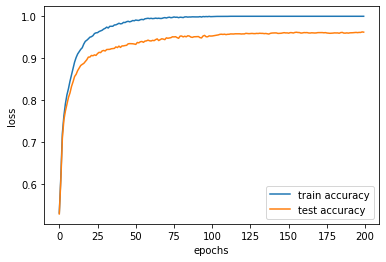

In [31]:
%matplotlib inline
import matplotlib.pyplot as plt

# Visualization of the loss over the epochs
fig, ax = plt.subplots(figsize=(6, 4))

plt.plot(rounds_stats["tr_acc_hist"].mean(0), label='train accuracy')
plt.plot(rounds_stats["te_acc_hist"].mean(0), label='test accuracy')
ax.legend()
plt.xlabel('epochs')
plt.ylabel('loss');